# Práctica 4 · Notebook 02: Medidas de variabilidad
**Dataset:** ENDIREH 2021 · **Framework:** polars

**Pregunta que contesta este notebook:** ¿qué tan dispersos están los datos respecto a su valor central?
Calculamos rango, varianza, desviación estándar, coeficiente de variación (CV) e IQR, sin ponderar y ponderado,
y comparamos entre mujeres que **sí** y **no** reportaron violencia de pareja.

In [1]:
import sys
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# --- Para que el notebook encuentre config/ y src/ (corre desde la carpeta notebooks/ del repo)
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(RAIZ))

try:
    # Modo repo (VS Code / Jupyter dentro del proyecto)
    from src import descriptivas as d
    try:
        from config import rutas as r
    except ImportError:
        r = None
    ARCHIVO_LIMPIO = getattr(r, "ARCHIVO_LIMPIO", RAIZ / "data" / "data-processed" / "endireh_2021_clean.parquet")
    RUTA_FIGURAS = getattr(r, "RUTA_FIGURAS", RAIZ / "reports" / "figures")
except ImportError:
    # Modo Colab: te pide subir 2 archivos (descriptivas.py y el .parquet)
    ARCHIVO_LIMPIO = Path("endireh_2021_clean.parquet")
    RUTA_FIGURAS = Path("figures")
    if not (Path("descriptivas.py").exists() and ARCHIVO_LIMPIO.exists()):
        from google.colab import files
        print("Sube estos 2 archivos: descriptivas.py y endireh_2021_clean.parquet")
        files.upload()
    sys.path.append(str(Path.cwd()))
    import descriptivas as d

RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")
print("Archivo de datos:", ARCHIVO_LIMPIO)

Archivo de datos: C:\Users\super\Documents\AyrosCyrsBack\Practica-3---Polars\data\data-processed\endireh_2021_clean.parquet


## Paso 1. Cargar los datos limpios

In [2]:
df = pl.read_parquet(ARCHIVO_LIMPIO)
print("Dimensiones:", df.shape)

VARS = ["edad_primer_union", "num_hijos"]   # variables cuantitativas principales
PESO = "factor_expansion"                   # a cuántas mujeres representa cada fila

# Solo quitamos filas con nulos en lo que vamos a usar
df_ok = df.drop_nulls(subset=VARS + [PESO])
print("Filas que usamos:", df_ok.height)
df_ok.select(VARS + [PESO]).describe()

Dimensiones: (105296, 26)
Filas que usamos: 105296


statistic,edad_primer_union,num_hijos,factor_expansion
str,f64,f64,f64
"""count""",105296.0,105296.0,105296.0
"""null_count""",0.0,0.0,0.0
"""mean""",21.606927,2.605759,466.235944
"""std""",6.554,1.091477,519.936476
"""min""",12.0,1.0,12.0
"""25%""",21.0,1.0,175.0
"""50%""",21.0,3.0,300.0
"""75%""",21.0,3.0,563.0
"""max""",98.0,4.0,8836.0


## Paso 2. Variabilidad SIN ponderar
- **Rango** = máximo − mínimo
- **Varianza** y **desviación estándar** = qué tanto se alejan, en promedio, los datos de la media
- **CV** = desviación / media × 100 (sirve para comparar dispersión entre grupos con medias distintas)
- **IQR** = Q3 − Q1 (el "ancho" del 50 % central de los datos)

In [3]:
var_sin = {v: d.resumen_variabilidad(df_ok[v].to_numpy()) for v in VARS}
pl.DataFrame([{"variable": v, **vals} for v, vals in var_sin.items()])

variable,rango,varianza,desv_est,CV_%,IQR
str,f64,f64,f64,f64,f64
"""edad_primer_union""",86.0,42.954918,6.554,30.332866,0.0
"""num_hijos""",3.0,1.191322,1.091477,41.887107,2.0


## Paso 3. Variabilidad PONDERADA por `factor_expansion`

In [4]:
pesos = df_ok[PESO].to_numpy()
var_pond = {v: d.resumen_variabilidad_pond(df_ok[v].to_numpy(), pesos) for v in VARS}
pl.DataFrame([{"variable": v, **vals} for v, vals in var_pond.items()])

variable,rango,varianza_pond,desv_est_pond,CV_%_pond,IQR_pond
str,f64,f64,f64,f64,f64
"""edad_primer_union""",86.0,43.564849,6.600367,30.55776,0.0
"""num_hijos""",3.0,1.099709,1.04867,40.109924,2.0


## Paso 4. Comparación entre mujeres con y sin violencia de pareja
`sufrio_violencia_pareja`: 1 = sí reportó, 0 = no reportó.
Comparamos el **CV** porque las medias de los dos grupos son distintas.

In [5]:
etiquetas = {1: "Sí reportó violencia de pareja", 0: "No reportó violencia de pareja"}
filas = []
for valor, nombre in etiquetas.items():
    g = df_ok.filter(pl.col("sufrio_violencia_pareja") == valor)
    for v in VARS:
        x, w = g[v].to_numpy(), g[PESO].to_numpy()
        s, p = d.resumen_variabilidad(x), d.resumen_variabilidad_pond(x, w)
        filas.append({
            "grupo": nombre, "variable": v, "n": g.height,
            "media": d.resumen_localizacion(x)["media"],
            "desv_est": s["desv_est"], "CV_%": s["CV_%"], "IQR": s["IQR"],
            "CV_%_pond": p["CV_%_pond"], "IQR_pond": p["IQR_pond"],
        })
por_grupo = pl.DataFrame(filas)
por_grupo

grupo,variable,n,media,desv_est,CV_%,IQR,CV_%_pond,IQR_pond
str,str,i64,f64,f64,f64,f64,f64,f64
"""Sí reportó violencia de pareja""","""edad_primer_union""",19107,21.876904,7.970362,36.432769,0.0,35.238842,0.0
"""Sí reportó violencia de pareja""","""num_hijos""",19107,2.54221,1.158367,45.565367,2.0,45.52652,2.0
"""No reportó violencia de pareja""","""edad_primer_union""",86189,21.547077,6.194786,28.750005,0.0,29.416512,0.0
"""No reportó violencia de pareja""","""num_hijos""",86189,2.619847,1.075584,41.055228,2.0,38.894201,2.0


## Paso 5. Alerta: IQR igual a 0
Un IQR de 0 quiere decir que Q1 y Q3 valen lo mismo: el 50 % central de los datos es **un solo valor**.
Lo revisamos para `edad_primer_union`:

In [6]:
for v in VARS:
    moda = d.resumen_localizacion(df_ok[v].to_numpy())["moda"]
    prop = d.proporcion_valor(df_ok[v].to_numpy(), moda)
    print(f"{v}: IQR = {var_sin[v]['IQR']:.1f} | el {prop:.1%} de las filas vale {moda:.0f}")

edad_primer_union: IQR = 0.0 | el 92.2% de las filas vale 21
num_hijos: IQR = 2.0 | el 50.4% de las filas vale 3


## Paso 6. Gráficas
### 6.1 Histogramas ponderados por grupo

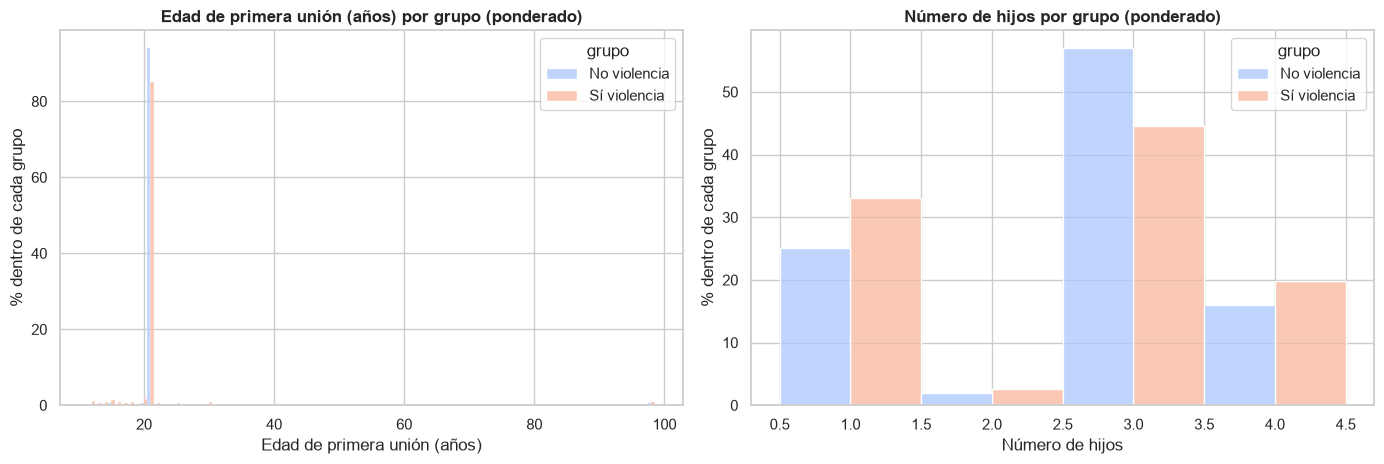

In [7]:
pdf = df_ok.select(VARS + [PESO, "sufrio_violencia_pareja"]).to_pandas()
pdf["grupo"] = pdf["sufrio_violencia_pareja"].map({1: "Sí violencia", 0: "No violencia"})
titulos = {"edad_primer_union": "Edad de primera unión (años)", "num_hijos": "Número de hijos"}

fig, ejes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, v in zip(ejes, VARS):
    sns.histplot(data=pdf, x=v, weights=PESO, hue="grupo", discrete=True, stat="percent",
                 common_norm=False, multiple="dodge", palette="coolwarm", ax=ax)
    ax.set_title(f"{titulos[v]} por grupo (ponderado)", fontweight="bold")
    ax.set_xlabel(titulos[v]); ax.set_ylabel("% dentro de cada grupo")
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "02_histogramas_variabilidad.png", dpi=150)
plt.show()

### 6.2 Diagramas de caja (boxplots)
Los boxplots de seaborn **no** usan el factor de expansión (describen a las encuestadas, no al país). Lo decimos explícito en el título.

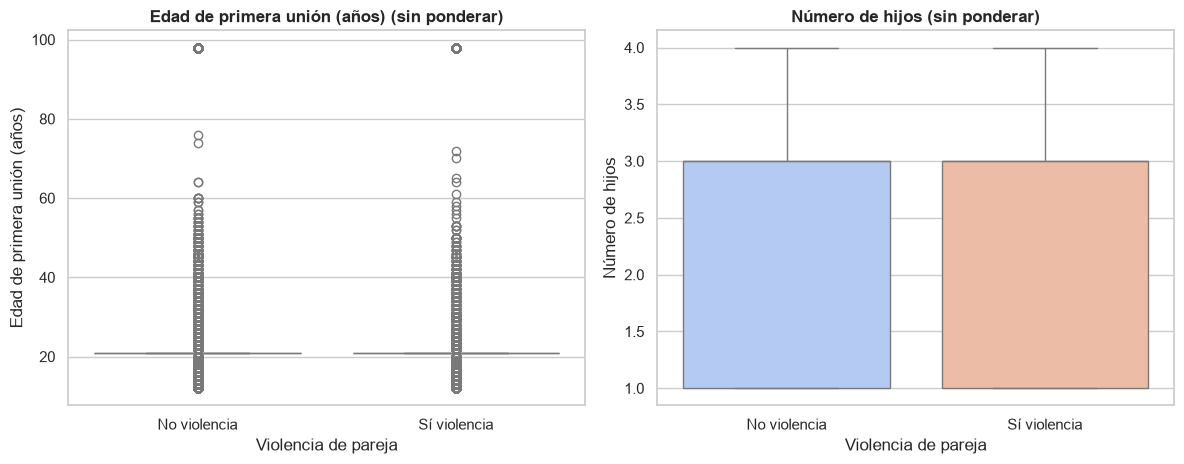

In [8]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, v in zip(ejes, VARS):
    sns.boxplot(data=pdf, x="grupo", y=v, hue="grupo", palette="coolwarm", legend=False, ax=ax)
    ax.set_title(f"{titulos[v]} (sin ponderar)", fontweight="bold")
    ax.set_xlabel("Violencia de pareja"); ax.set_ylabel(titulos[v])
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "02_boxplots_variabilidad.png", dpi=150)
plt.show()

## Paso 7. Filas para la tabla-resumen del reporte
Copia estos valores a las filas de **Localización** y **Variabilidad** de la tabla del Paso 5 de la práctica.

In [9]:
loc = {v: d.resumen_localizacion_pond(df_ok[v].to_numpy(), pesos) for v in VARS}
for v in VARS:
    print(f"LOCALIZACIÓN  | {v} | media pond = {loc[v]['media_pond']:.2f}, mediana pond = {loc[v]['mediana_pond']:.2f}")
for v in VARS:
    print(f"VARIABILIDAD  | {v} | CV pond = {var_pond[v]['CV_%_pond']:.1f} %, IQR pond = {var_pond[v]['IQR_pond']:.1f}")

LOCALIZACIÓN  | edad_primer_union | media pond = 21.60, mediana pond = 21.00
LOCALIZACIÓN  | num_hijos | media pond = 2.61, mediana pond = 3.00
VARIABILIDAD  | edad_primer_union | CV pond = 30.6 %, IQR pond = 0.0
VARIABILIDAD  | num_hijos | CV pond = 40.1 %, IQR pond = 2.0


In [ ]:
## Paso 8. Interpretación

In [ ]:
- **CV ponderado:** `edad_primer_union` tiene CV de 30.6 % y `num_hijos` de 40.1 %. El número de hijos varía más, en términos relativos, que la edad de unión.
- **IQR:** el de la edad es 0.0 y el de hijos es 2.0. Un IQR de 0 significa que la mitad central de los datos es un solo valor, lo que confirma la alerta del Paso 5 (92.2 % de las filas vale 21).
- **Por grupo:** el CV de `edad_primer_union` fue 36.43 % en mujeres que reportaron violencia de pareja y 28.75 % en las que no; el de `num_hijos`, 45.56 % y 41.05 %. Un CV mayor significa más dispersión relativa en ese grupo.
- **Ojo con no sacar conclusiones de más:** que un grupo varíe más no significa que la edad de unión cause la violencia; solo dice que ese grupo es más variado.
- **Limitación:** como la mayoría de las filas vale lo mismo, el IQR y el CV subestiman la variabilidad real.
- **Sensibilidad del tema:** estas medidas describen grupos de mujeres, no explican por qué ocurre la violencia ni señalan culpables.